In [21]:
import pandas as pd
import numpy as np
import joblib
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [6]:
# Load processed data set

df = pd.read_csv("../data/sepsis_model_data.csv")

df.head()

,age,sex,episode,age_episode_interaction,outcome
0,21,1,1,21,1
1,20,1,1,20,1
2,21,1,1,21,1
3,77,0,1,77,1
4,72,0,1,72,1


In [7]:
# Seperate features and target
X = df.drop('outcome', axis=1)
y = df['outcome']



In [8]:
X.head()

,age,sex,episode,age_episode_interaction
0,21,1,1,21
1,20,1,1,20
2,21,1,1,21
3,77,0,1,77
4,72,0,1,72


In [11]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
#Class Weight for XGBoost. We are adding this to handle class imbalance in the dataset. This will help the model to focus more on the minority class (survival) and improve its performance on that class.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

In [16]:
models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        class_weights=[1, scale_pos_weight],
        verbose=0,
        random_state=42
    )
}


In [17]:
results = []

In [18]:
# Train and evaluate each model
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    recall_death = report['0']['recall']

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Recall (Death)": recall_death,
        "ROC-AUC": roc
    })

In [19]:
# Model comparison

results_df = pd.DataFrame(results)

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Recall (Death),ROC-AUC
0,Logistic Regression,0.579375,0.742751,0.713975
3,CatBoost,0.539041,0.779766,0.710332
2,XGBoost,0.537090,0.781616,0.709874
1,Random Forest,0.559321,0.745836,0.703501


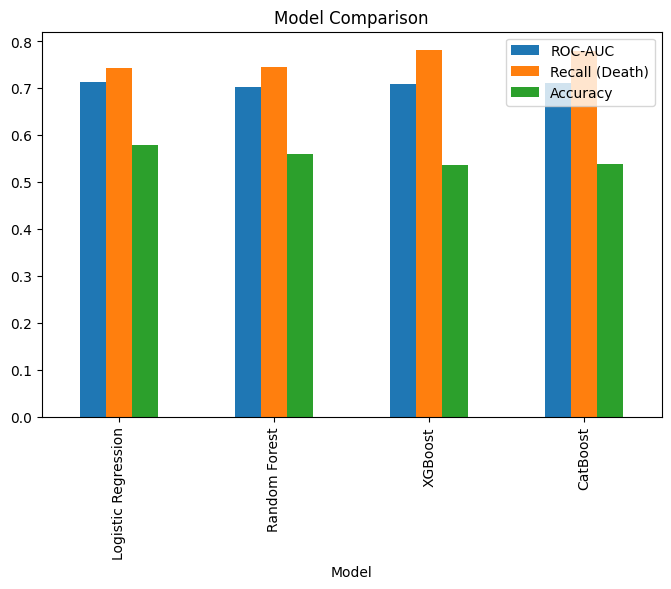

In [20]:
# Showing model performance in a graphical format
results_df.set_index("Model")[["ROC-AUC","Recall (Death)", "Accuracy"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.show()

In [41]:
# Save all models to disk 

os.makedirs("models", exist_ok=True)


In [42]:
for model_name, model in models.items():

    model.fit(X_train, y_train)

    filename = f"models/{model_name.replace(' ','_').lower()}_model.pkl"

    joblib.dump(model, filename)

    print(f"{model_name} saved to {filename}")

Logistic Regression saved to models/logistic_regression_model.pkl
Random Forest saved to models/random_forest_model.pkl
XGBoost saved to models/xgboost_model.pkl
CatBoost saved to models/catboost_model.pkl


Model Comparison Interpretation

Four models were evaluated for predicting sepsis survival outcomes.

Logistic Regression achieved the highest ROC-AUC score (0.714),
indicating the best overall discrimination between survival and
mortality cases.

XGBoost and CatBoost showed higher recall for mortality prediction,
detecting approximately 78% of death cases, which may be valuable
for early ICU risk identification.

In [24]:
best_model_name = results_df.sort_values(
    by="ROC-AUC", ascending=False).iloc[0]["Model"]

best_model = models[best_model_name]

import joblib

joblib.dump(best_model, "../models/sepsis_best_model.pkl")

['../models/sepsis_best_model.pkl']

# Advanced Modeling Pipeline--- Regression Model s
Stratified K-Fold + SMOTE + Hyperparameter Tuning

In [27]:

# Defining the XGBoost model

xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

In [28]:
# Building a pipeline with SMOTE and XGBoost

pipeline = Pipeline([
    
    ("smote", SMOTE(random_state=42)),
    
    ("model", xgb_model)
])

In [29]:
#define the parameter grid for hyperparameter tuning
param_grid = {

    "model__n_estimators": [100, 200],

    "model__max_depth": [3, 5, 7],

    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__subsample": [0.8, 1.0]
}

In [30]:
# Setup stratified k-fold cross-validation

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#This ensures each fold has:same class distribution

In [31]:
#grid search with cross-validation

grid_search = GridSearchCV(

    pipeline,

    param_grid,

    cv=skf,

    scoring="roc_auc",

    n_jobs=-1,

    verbose=2
)

In [32]:
# Train the pipeline with grid search

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [33]:
grid_search.best_params_

{'model__learning_rate': 0.01,
 'model__max_depth': 3,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

In [34]:
grid_search.best_params_

{'model__learning_rate': 0.01,
 'model__max_depth': 3,
 'model__n_estimators': 200,
 'model__subsample': 0.8}

In [35]:
# Test the best model on the test set

best_model = grid_search.best_estimator_

death_prob = best_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, death_prob)



0.7130939958587128

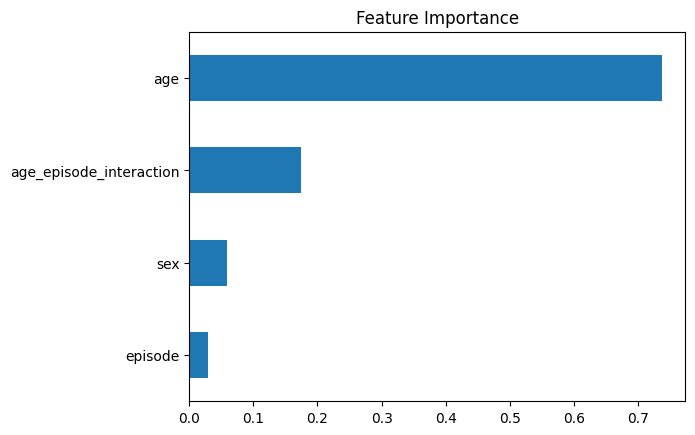

In [36]:
importance = best_model.named_steps["model"].feature_importances_

features = X.columns

pd.Series(importance, index=features)\
    .sort_values()\
    .plot(kind="barh")

plt.title("Feature Importance")
plt.show()

In [37]:
# Save the best model
import joblib

joblib.dump(best_model, "../models/sepsis_final_model.pkl")

['../models/sepsis_final_model.pkl']

In [38]:
X.columns

Index(['age', 'sex', 'episode', 'age_episode_interaction'], dtype='object')

In [39]:
X.dtypes

age                        int64
sex                        int64
episode                    int64
age_episode_interaction    int64
dtype: object